# Parallel CNN-LSTM Model with Bayesian Optimization

This notebook implements a parallel architecture where CNN and LSTM branches process the same input simultaneously, with comprehensive Bayesian optimization and robustness features.

In [1]:
import os
import h5py
import time
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import h5py
import time
import matplotlib
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from deap import algorithms, base, creator, tools
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, TimeDistributed
from keras.models import Sequential
from keras.layers import Dense, Conv1D
from keras.layers import Dropout, Input
from keras import initializers
from keras.layers import MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D
from keras.models import Model
from keras.layers import TimeDistributed, Flatten, Concatenate
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import keras_tuner as kt
from datetime import datetime
%matplotlib inline

In [2]:
filename = 'N-CMAPSS_DS05.h5'

In [3]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("Y shape: " + str(Y.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.05416666666666667

W shape: (6912652, 4)
X_s shape: (6912652, 14)
X_v shape: (6912652, 14)
Y shape: (6912652, 1)
T shape: (6912652, 10)
A shape: (6912652, 4)


In [4]:
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0)
A = np.concatenate((A_dev, A_test), axis=0) 

X = np.concatenate((W, X_s, A, Y), axis=1)
Y=  np.concatenate((A, Y), axis=1)
Y = DataFrame(data=Y, columns=A_var+['Y'])
X = DataFrame(data=X, columns=W_var+X_s_var+A_var+['Y'])

In [5]:
Y.describe()

,unit,cycle,Fc,hs,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01,3.900481e+01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01,2.376696e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00,1.900000e+01
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00,3.800000e+01
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00,5.800000e+01
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00,9.900000e+01


In [6]:
Y.drop("cycle",axis=1,inplace=True)
Y.drop("Fc",axis=1,inplace=True)
Y.drop("hs",axis=1,inplace=True)
Y.describe()

,unit,Y
count,6.912652e+06,6.912652e+06
mean,5.239374e+00,3.900481e+01
std,2.904136e+00,2.376696e+01
min,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.900000e+01
50%,6.000000e+00,3.800000e+01
75%,8.000000e+00,5.800000e+01
max,1.000000e+01,9.900000e+01


In [7]:
X.drop("cycle",axis=1,inplace=True)
X.drop("Fc",axis=1,inplace=True)
X.drop("hs",axis=1,inplace=True)
X.drop("alt",axis=1,inplace=True)
X.describe()

,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,unit,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.319760e-01,5.996256e+01,4.909356e+02,5.699286e+02,1.334474e+03,1.638378e+03,1.129818e+03,1.304474e+01,1.019378e+01,1.324339e+01,1.606218e+01,2.379398e+02,2.422144e+02,1.019697e+01,1.953364e+03,8.248141e+03,2.548930e+00,5.239374e+00,3.900481e+01
std,1.208898e-01,1.834395e+01,1.985279e+01,2.112542e+01,6.869315e+01,1.239105e+02,6.251462e+01,2.883393e+00,2.421477e+00,2.927303e+00,3.450926e+00,5.919650e+01,6.003612e+01,2.758136e+00,1.873247e+02,2.277543e+02,7.877672e-01,2.904136e+00,2.376696e+01
min,3.150000e-04,2.355452e+01,4.369255e+02,4.998511e+02,1.091806e+03,1.095354e+03,7.923581e+02,6.700688e+00,5.285918e+00,6.802729e+00,8.186232e+00,9.248497e+01,9.466065e+01,4.635623e+00,1.471000e+03,7.429764e+03,5.963687e-01,1.000000e+00,0.000000e+00
25%,4.393620e-01,4.631803e+01,4.741667e+02,5.546204e+02,1.287931e+03,1.552724e+03,1.085702e+03,1.049740e+01,7.972020e+00,1.065726e+01,1.319101e+01,1.929589e+02,1.965787e+02,7.665725e+00,1.835894e+03,8.094517e+03,1.980253e+00,2.000000e+00,1.900000e+01
50%,5.371380e-01,6.257768e+01,4.960515e+02,5.678197e+02,1.329839e+03,1.647608e+03,1.120127e+03,1.338949e+01,1.060965e+01,1.359339e+01,1.617596e+01,2.256779e+02,2.301263e+02,1.051082e+01,1.997333e+03,8.237001e+03,2.340848e+00,6.000000e+00,3.800000e+01
75%,6.330240e-01,7.664008e+01,5.072438e+02,5.838195e+02,1.373982e+03,1.711727e+03,1.165307e+03,1.528072e+01,1.209400e+01,1.551342e+01,1.847904e+01,2.724938e+02,2.773639e+02,1.232305e+01,2.112084e+03,8.383625e+03,2.948869e+00,8.000000e+00,5.800000e+01
max,7.492590e-01,8.876890e+01,5.343834e+02,6.341967e+02,1.540888e+03,1.993206e+03,1.356282e+03,2.044899e+01,1.568410e+01,2.076040e+01,2.643985e+01,4.485121e+02,4.553945e+02,1.672457e+01,2.285550e+03,8.921408e+03,5.607345e+00,1.000000e+01,9.900000e+01


In [8]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00


In [9]:
print('Engine units in df: ', np.unique(X['unit']))
print('Engine units in df: ', np.unique(Y['unit']))

Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [10]:
X_train= X.loc[(X.unit == 1) | (X.unit == 3) | (X.unit == 5) | (X.unit == 6) | (X.unit == 7) | (X.unit == 9) | (X.unit == 10) ]
Y_train=Y.loc[(Y.unit == 1) | (Y.unit == 3) | (Y.unit == 5) |  (Y.unit == 6) | (Y.unit == 7) | (Y.unit == 9) | (Y.unit == 10) ]
X_test=X.loc[(X.unit == 2) | (X.unit == 4) | (X.unit == 8) ]
Y_test=Y.loc[(Y.unit == 2) | (Y.unit == 4) | (Y.unit == 8) ]

In [11]:
print('Engine units in df: ', np.unique(X_train['unit']))
print('Engine units in df: ', np.unique(Y_train['unit']))
print('Engine units in df: ', np.unique(X_test['unit']))
print('Engine units in df: ', np.unique(Y_test['unit']))
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [2. 4. 8.]
Engine units in df:  [2. 4. 8.]
X_train size is  (4900033, 19)
X_test size is  (2012619, 19)
y_train size is  (4900033, 2)
y_test size is  (2012619, 2)


In [12]:
X_train.drop("unit",axis=1,inplace=True)
X_test.drop("unit",axis=1,inplace=True)
X_train.drop("Y",axis=1,inplace=True)
X_test.drop("Y",axis=1,inplace=True)
Y_train.drop("unit",axis=1,inplace=True)
Y_test.drop("unit",axis=1,inplace=True)
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("unit",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("unit",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("Y",axis=1,i

X_train size is  (4900033, 17)
X_test size is  (2012619, 17)
y_train size is  (4900033, 1)
y_test size is  (2012619, 1)


C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("Y",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_train.drop("unit",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_655080\816249269.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test.drop("unit",axis=1,in

In [ ]:
# ========== FIX FOR DATA LEAKAGE ==========
# Create validation set from training data to avoid leakage
# The test set will remain completely isolated until final evaluation

print("\n" + "="*70)
print("CREATING VALIDATION SET FROM TRAINING DATA")
print("="*70)

# Split training data into train and validation (80-20 split)
from sklearn.model_selection import train_test_split

X_train_split, X_val, Y_train_split, Y_val = train_test_split(
    X_train, Y_train,
    test_size=0.2,
    random_state=42
)

print(f"\nOriginal training set size: {X_train.shape}")
print(f"New training set size: {X_train_split.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size (ISOLATED): {X_test.shape}")

print(f"\nOriginal Y_train size: {Y_train.shape}")
print(f"New Y_train_split size: {Y_train_split.shape}")
print(f"Y_val size: {Y_val.shape}")
print(f"Y_test size (ISOLATED): {Y_test.shape}")

print("\n" + "="*70)
print("DATA SPLIT SUMMARY:")
print("="*70)
print("✓ Training set: Used for model training")
print("✓ Validation set: Used for hyperparameter tuning (Bayesian Optimization)")
print("✓ Test set: COMPLETELY ISOLATED - Used only for final evaluation")
print("="*70 + "\n")


In [13]:
# Data normalization
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN/LSTM input (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape after reshaping:", X_train.shape)
print("X_test shape after reshaping:", X_test.shape)

X_train shape after reshaping: (4900033, 17, 1)
X_test shape after reshaping: (2012619, 17, 1)


## Parallel CNN-LSTM Model with Bayesian Optimization

This section implements a parallel architecture where CNN and LSTM branches process the same input simultaneously, then their outputs are concatenated and fed to dense layers.

In [14]:
def create_parallel_model(hp):
    """
    Creates a parallel CNN-LSTM model with tunable hyperparameters.
    CNN and LSTM branches work on the same input simultaneously.
    """
    # Input layer
    input_layer = Input(shape=(X_train.shape[1], 1))
    
    # ==================== CNN BRANCH ====================
    cnn_branch = input_layer
    
    # Tune the number of CNN layers
    num_cnn_layers = hp.Int("num_cnn_layers", 1, 4)
    
    for i in range(num_cnn_layers):
        cnn_branch = Conv1D(
            filters=hp.Int(f"cnn_{i}_filters", min_value=32, max_value=128, step=16),
            kernel_size=hp.Int(f"cnn_{i}_kernel", min_value=3, max_value=7, step=2),
            activation="relu",
            padding="same"  # Use 'same' padding to maintain sequence length
        )(cnn_branch)
        
        # Add dropout after each CNN layer
        cnn_branch = Dropout(rate=hp.Float(f"cnn_{i}_dropout", min_value=0.0, max_value=0.3, step=0.1))(cnn_branch)
        
        # Only add pooling for the first few layers to avoid dimension issues
        if i < 2:  # Only pool in first 2 layers
            cnn_branch = MaxPooling1D(pool_size=2, padding="same")(cnn_branch)
    
    # Global pooling for CNN branch
    cnn_pooling_type = hp.Choice("cnn_pooling", ["max", "avg"])
    if cnn_pooling_type == "max":
        cnn_output = GlobalMaxPooling1D()(cnn_branch)
    else:
        cnn_output = GlobalAveragePooling1D()(cnn_branch)
    
    # ==================== LSTM BRANCH ====================
    lstm_branch = input_layer
    
    # Tune the number of LSTM layers
    num_lstm_layers = hp.Int("num_lstm_layers", 1, 3)
    
    for i in range(num_lstm_layers):
        return_sequences = True if i < num_lstm_layers - 1 else False
        
        lstm_branch = LSTM(
            units=hp.Int(f"lstm_{i}_units", min_value=32, max_value=128, step=16),
            return_sequences=return_sequences,
            dropout=hp.Float(f"lstm_{i}_dropout", min_value=0.0, max_value=0.3, step=0.1),
            recurrent_dropout=hp.Float(f"lstm_{i}_recurrent_dropout", min_value=0.0, max_value=0.3, step=0.1)
        )(lstm_branch)
    
    lstm_output = lstm_branch
    
    # ==================== MERGE BRANCHES ====================
    # Concatenate CNN and LSTM outputs
    merged = Concatenate()([cnn_output, lstm_output])
    
    # ==================== DENSE LAYERS ====================
    # Tune the number of dense layers
    num_dense_layers = hp.Int("num_dense_layers", 1, 3)
    
    x = merged
    for i in range(num_dense_layers):
        x = Dense(
            units=hp.Int(f"dense_{i}_units", min_value=32, max_value=256, step=32),
            activation="relu"
        )(x)
        x = Dropout(rate=hp.Float(f"dense_{i}_dropout", min_value=0.0, max_value=0.5, step=0.1))(x)
    
    # Output layer
    output_layer = Dense(1, activation="linear")(x)
    
    # Create the model
    model = Model(inputs=input_layer, outputs=output_layer)
    
    # Compile the model
    optimizer_choice = hp.Choice("optimizer", ["adam", "rmsprop", "sgd"])
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    if optimizer_choice == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )
    
    return model

In [15]:
# Initialize Bayesian Optimization tuner with robust checkpointing
import os
from datetime import datetime

# Create a unique project directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
project_dir = f"parallel_bayesian_optimization_{timestamp}"

# Check if we want to resume from a previous run
resume_project = input("Do you want to resume from a previous run? (y/n): ").lower().strip()

if resume_project == 'y':
    # List available project directories
    available_dirs = [d for d in os.listdir('.') if d.startswith('parallel_bayesian_optimization_') and os.path.isdir(d)]
    if available_dirs:
        print("Available previous runs:")
        for i, dir_name in enumerate(available_dirs):
            print(f"{i+1}. {dir_name}")
        
        choice = int(input("Enter the number of the run to resume: ")) - 1
        if 0 <= choice < len(available_dirs):
            project_dir = available_dirs[choice]
            print(f"Resuming from: {project_dir}")
        else:
            print("Invalid choice. Starting new run.")
    else:
        print("No previous runs found. Starting new run.")

tuner = kt.BayesianOptimization(
    create_parallel_model,
    objective="val_loss",
    max_trials=30,  # Increased trials for comprehensive search
    directory=".",
    project_name=project_dir,
    overwrite=False  # Set to False to enable resumption
)

print(f"Tuner initialized successfully! Project: {project_dir}")
print(f"Trials completed so far: {len(tuner.oracle.trials)}")
print(f"Search space summary:")
tuner.search_space_summary()

Available previous runs:
1. parallel_bayesian_optimization_20251014_195549
2. parallel_bayesian_optimization_20251016_074142
Resuming from: parallel_bayesian_optimization_20251014_195549
Reloading Tuner from .\parallel_bayesian_optimization_20251014_195549\tuner0.json
Tuner initialized successfully! Project: parallel_bayesian_optimization_20251014_195549
Trials completed so far: 30
Search space summary:
Search space summary
Default search space size: 33
num_cnn_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
cnn_0_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
cnn_0_kernel (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 7, 'step': 2, 'sampling': 'linear'}
cnn_0_dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
cnn_pooling (Choice)
{'default': 'max', 'condit

In [ ]:
#Don't run
# 
#  === Skip exactly the NEXT trial once (past trials kept) ===
import types

# Try both keras_tuner and kerastuner (for compatibility)
try:
    from keras_tuner.engine import trial as _kt_trial
except Exception:
    try:
        from kerastuner.engine import trial as _kt_trial
    except Exception:
        _kt_trial = None

_KT_INVALID = getattr(_kt_trial.TrialStatus, "INVALID", "INVALID") if _kt_trial else "INVALID"

# Ensure tuner exists
if "tuner" not in globals():
    raise RuntimeError("Run the tuner creation cell first, then this patch cell.")

# Backup original run_trial
__orig_run_trial = tuner.run_trial
__skip_flag = {"once": True}

def __skip_once_run_trial(self, trial, *args, **kwargs):
    """Skip exactly one pending trial and mark it INVALID."""
    if __skip_flag["once"]:
        tid = getattr(trial, "trial_id", "unknown")
        print(f"[SkipOnce] Skipping trial {tid} and marking it as INVALID.")
        try:
            self.oracle.end_trial(trial_id=trial.trial_id, status=_KT_INVALID)
        except Exception:
            try:
                self.oracle.end_trial(trial_id=trial.trial_id, status="INVALID")
            except Exception:
                print("[SkipOnce] Warning: could not mark trial INVALID properly.")
        # Persist oracle state if possible
        for attr in ("save", "_save_trial"):
            func = getattr(self.oracle, attr, None)
            if callable(func):
                try:
                    func(trial)
                except Exception:
                    pass
        __skip_flag["once"] = False
        return  # Skip execution
    # Continue normal trials afterward
    return __orig_run_trial(trial, *args, **kwargs)

# Apply temporary patch
tuner.run_trial = types.MethodType(__skip_once_run_trial, tuner)
print("✅ Patch active: the NEXT trial will be skipped and marked INVALID. Others continue normally.")


✅ Patch active: the NEXT trial will be skipped and marked INVALID. Others continue normally.


In [16]:
# Start the hyperparameter search with robust error handling
print("Starting Parallel CNN-LSTM Bayesian optimization search...")
print(f"Remaining trials: {tuner.oracle.max_trials - len(tuner.oracle.trials)}")

try:
    # Add callbacks for better monitoring and checkpointing
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7
        )
    ]
    
    tuner.search(
        X_train_split, Y_train_split, 
        epochs=20,  # Increased epochs with early stopping
        batch_size=32,
        validation_data=(X_val, Y_val)  # Use validation set, not test set,
        callbacks=callbacks,
        verbose=1
    )
    
    print("Hyperparameter search completed successfully!")
    
except KeyboardInterrupt:
    print("\nSearch interrupted by user. Progress has been saved.")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("You can resume this search later by running the previous cell and selecting 'y' to resume.")
    
except Exception as e:
    print(f"\nAn error occurred during search: {str(e)}")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("Progress has been saved. You can resume this search later.")

print(f"\nTotal completed trials: {len(tuner.oracle.trials)}")
print(f"Project saved in: {project_dir}")

Starting Parallel CNN-LSTM Bayesian optimization search...
Remaining trials: 0
Hyperparameter search completed successfully!

Total completed trials: 30
Project saved in: parallel_bayesian_optimization_20251014_195549


In [18]:
# Check current progress and get results
print(f"Current progress: {len(tuner.oracle.trials)} trials completed out of {tuner.oracle.max_trials}")

if len(tuner.oracle.trials) == 0:
    print("No trials completed yet. Please run the search first.")
else:
    # Display results summary
    tuner.results_summary()
    
    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Current progress: 30 trials completed out of 30
Results summary
Results in .\parallel_bayesian_optimization_20251014_195549
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 04 summary
Hyperparameters:
num_cnn_layers: 4
cnn_0_filters: 128
cnn_0_kernel: 3
cnn_0_dropout: 0.1
cnn_pooling: avg
num_lstm_layers: 3
lstm_0_units: 80
lstm_0_dropout: 0.0
lstm_0_recurrent_dropout: 0.0
num_dense_layers: 3
dense_0_units: 96
dense_0_dropout: 0.30000000000000004
optimizer: rmsprop
learning_rate: 0.0001
cnn_1_filters: 64
cnn_1_kernel: 5
cnn_1_dropout: 0.2
cnn_2_filters: 64
cnn_2_kernel: 5
cnn_2_dropout: 0.2
cnn_3_filters: 32
cnn_3_kernel: 3
cnn_3_dropout: 0.0
lstm_1_units: 32
lstm_1_dropout: 0.0
lstm_1_recurrent_dropout: 0.0
dense_1_units: 192
dense_1_dropout: 0.4
dense_2_units: 96
dense_2_dropout: 0.2
lstm_2_units: 64
lstm_2_dropout: 0.0
lstm_2_recurrent_dropout: 0.0
Score: 66.98344421386719

Trial 26 summary
Hyperparameters:
num_cnn_layers: 4
cnn_0_filters: 96
cnn_0_kernel: 3

In [19]:
# Display best hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    print("\n" + "="*60)
    print("BEST HYPERPARAMETERS FOR PARALLEL CNN-LSTM MODEL:")
    print("="*60)
    
    # Architecture parameters
    print("\n🏗️  ARCHITECTURE:")
    print(f"   CNN Layers: {best_hps.get('num_cnn_layers')}")
    print(f"   LSTM Layers: {best_hps.get('num_lstm_layers')}")
    print(f"   Dense Layers: {best_hps.get('num_dense_layers')}")
    print(f"   CNN Pooling: {best_hps.get('cnn_pooling')}")
    
    # Optimizer parameters
    print("\n⚙️  OPTIMIZER:")
    print(f"   Type: {best_hps.get('optimizer')}")
    print(f"   Learning Rate: {best_hps.get('learning_rate')}")
    
    # CNN branch details
    print("\n🔍 CNN BRANCH DETAILS:")
    for i in range(best_hps.get('num_cnn_layers')):
        filters = best_hps.get(f'cnn_{i}_filters')
        kernel = best_hps.get(f'cnn_{i}_kernel')
        dropout = best_hps.get(f'cnn_{i}_dropout')
        print(f"   Layer {i+1}: {filters} filters, kernel={kernel}, dropout={dropout}")
    
    # LSTM branch details
    print("\n🔄 LSTM BRANCH DETAILS:")
    for i in range(best_hps.get('num_lstm_layers')):
        units = best_hps.get(f'lstm_{i}_units')
        dropout = best_hps.get(f'lstm_{i}_dropout')
        rec_dropout = best_hps.get(f'lstm_{i}_recurrent_dropout')
        print(f"   Layer {i+1}: {units} units, dropout={dropout}, recurrent_dropout={rec_dropout}")
    
    # Dense layers details
    print("\n🧠 DENSE LAYERS DETAILS:")
    for i in range(best_hps.get('num_dense_layers')):
        units = best_hps.get(f'dense_{i}_units')
        dropout = best_hps.get(f'dense_{i}_dropout')
        print(f"   Layer {i+1}: {units} units, dropout={dropout}")
    
    print("="*60)
else:
    print("No completed trials found. Please run the search first.")


BEST HYPERPARAMETERS FOR PARALLEL CNN-LSTM MODEL:

🏗️  ARCHITECTURE:
   CNN Layers: 4
   LSTM Layers: 3
   Dense Layers: 3
   CNN Pooling: avg

⚙️  OPTIMIZER:
   Type: rmsprop
   Learning Rate: 0.0001

🔍 CNN BRANCH DETAILS:
   Layer 1: 128 filters, kernel=3, dropout=0.1
   Layer 2: 64 filters, kernel=5, dropout=0.2
   Layer 3: 64 filters, kernel=5, dropout=0.2
   Layer 4: 32 filters, kernel=3, dropout=0.0

🔄 LSTM BRANCH DETAILS:
   Layer 1: 80 units, dropout=0.0, recurrent_dropout=0.0
   Layer 2: 32 units, dropout=0.0, recurrent_dropout=0.0
   Layer 3: 64 units, dropout=0.0, recurrent_dropout=0.0

🧠 DENSE LAYERS DETAILS:
   Layer 1: 96 units, dropout=0.30000000000000004
   Layer 2: 192 units, dropout=0.4
   Layer 3: 96 units, dropout=0.2


In [20]:
# Build the model with the optimal hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    model = tuner.hypermodel.build(best_hps)
    print("\n🏆 OPTIMAL PARALLEL CNN-LSTM MODEL ARCHITECTURE:")
    print("="*50)
    model.summary()
    
    # Visualize model architecture
    try:
        tf.keras.utils.plot_model(model, to_file='parallel_model_architecture.png', 
                                show_shapes=True, show_layer_names=True, rankdir='TB')
        print("\n📊 Model architecture diagram saved as 'parallel_model_architecture.png'")
    except:
        print("\n⚠️  Could not generate model diagram (graphviz not installed)")
        
else:
    print("Cannot build model - no completed trials found.")


🏆 OPTIMAL PARALLEL CNN-LSTM MODEL ARCHITECTURE:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 17, 1)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 17, 128)      512         ['input_1[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 17, 128)      0           ['conv1d[0][0]']                 
                                                                                                  
 max_pooling1d (MaxPooling1D)   (None, 9, 128)       0           ['dropout[0][0]']                
                                             

In [21]:
# ============================
# Resume-safe training (keeps history + can continue training)
# ============================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model

# ---- Config ----
run_dir = "runs/parallel_cnn_lstm"
os.makedirs(run_dir, exist_ok=True)

# Full-model checkpoints (Keras format recommended)
last_model_path = os.path.join(run_dir, "model_last.keras")        # latest state (resume from here)
best_model_path = os.path.join(run_dir, "model_best.keras")        # best val_loss

# Backward-compatible checkpoints (H5)
best_model_h5 = os.path.join(run_dir, "best_parallel_model.h5")
final_model_h5 = os.path.join(run_dir, "final_parallel_cnn_lstm_model.h5")

# Persistent history (survives crashes/restarts)
history_csv = os.path.join(run_dir, "history.csv")

# Training-state resume (optimizer state, epoch) after interruptions
backup_dir = os.path.join(run_dir, "backup_restore")

# Train this many MORE epochs from where you stopped
EXTRA_EPOCHS = 30

# Optional early stopping (set to False if you want to force all extra epochs)
USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 10

# ---- Ensure we have a model to train ----
# Priority:
# 1) existing `model` already built in memory
# 2) last checkpoint
# 3) best checkpoint
# 4) legacy best_parallel_model.h5 (root or run_dir)
if 'model' in globals() and model is not None:
    print("✅ Using existing `model` already in memory.")
else:
    loaded = False
    if os.path.exists(last_model_path):
        print(f"Loading last model: {last_model_path}")
        model = load_model(last_model_path)
        loaded = True
    elif os.path.exists(best_model_path):
        print(f"Loading best model: {best_model_path}")
        model = load_model(best_model_path)
        loaded = True
    elif os.path.exists(best_model_h5):
        print(f"Loading legacy best model: {best_model_h5}")
        model = load_model(best_model_h5)
        loaded = True
    elif os.path.exists("best_parallel_model.h5"):
        print("Loading legacy best model from working dir: best_parallel_model.h5")
        model = load_model("best_parallel_model.h5")
        loaded = True

    if not loaded:
        raise FileNotFoundError(
            "No model found to train. Build `model` first (from tuner/best_hps) or make sure a checkpoint exists in "
            f"'{run_dir}'."
        )

# ---- Ensure model is compiled (needed if you loaded a model without compile info) ----
try:
    _ = model.optimizer
except Exception:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )

# ---- Determine resume epoch from persistent history ----
start_epoch = 0
if os.path.exists(history_csv):
    try:
        hist_df = pd.read_csv(history_csv)
        start_epoch = len(hist_df)  # one row per epoch
        print(f"📌 Found existing history with {start_epoch} epochs in: {history_csv}")
    except Exception as e:
        print(f"⚠️ Could not read history.csv ({e}); starting from epoch 0.")
        start_epoch = 0
else:
    print("📌 No existing history.csv found; starting from epoch 0.")

target_epochs = start_epoch + EXTRA_EPOCHS
print(f"🚀 Training will run from epoch {start_epoch} to epoch {target_epochs} (EXTRA_EPOCHS={EXTRA_EPOCHS})")

# ---- Callbacks ----
callbacks = [
    tf.keras.callbacks.BackupAndRestore(backup_dir),                 # resume after interruption
    tf.keras.callbacks.CSVLogger(history_csv, append=True),          # persistent history (append)
    tf.keras.callbacks.ModelCheckpoint(                              
        best_model_path, monitor="val_loss", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(                              
        last_model_path, save_best_only=False, verbose=0
    ),
    # keep a legacy H5 best model too (so older cells/files still work)
    tf.keras.callbacks.ModelCheckpoint(
        best_model_h5, monitor="val_loss", save_best_only=True, verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

if USE_EARLY_STOPPING:
    callbacks.insert(
        0,
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=False,   # best is already stored separately
            verbose=1
        )
    )

# ---- Train (continue training) ----
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=target_epochs,
    initial_epoch=start_epoch,   # <-- key for "continue from where you stopped"
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training step completed.")
print(f"🧾 History appended to: {history_csv}")
print(f"💾 Best model saved to: {best_model_path}")
print(f"💾 Last model saved to: {last_model_path}")

# Optional: load best model into memory for evaluation/plots
if os.path.exists(best_model_path):
    model = load_model(best_model_path)
    print("✅ Loaded best model into `model` for the next cells.")


✅ Using existing `model` already in memory.
📌 No existing history.csv found; starting from epoch 0.
🚀 Training will run from epoch 0 to epoch 30 (EXTRA_EPOCHS=30)
Epoch 1/30
153127/153127 [==============================] - ETA: 0s - loss: 284.4668 - mean_absolute_error: 12.9652
Epoch 1: val_loss improved from inf to 263.23965, saving model to runs/parallel_cnn_lstm\model_best.keras
153127/153127 [==============================] - 6867s 45ms/step - loss: 284.4668 - mean_absolute_error: 12.9652 - val_loss: 263.2397 - val_mean_absolute_error: 11.9941 - lr: 1.0000e-04
Epoch 2/30
153127/153127 [==============================] - ETA: 0s - loss: 198.1198 - mean_absolute_error: 10.4830
Epoch 2: val_loss improved from 263.23965 to 246.18546, saving model to runs/parallel_cnn_lstm\model_best.keras
153127/153127 [==============================] - 6897s 45ms/step - loss: 198.1198 - mean_absolute_error: 10.4830 - val_loss: 246.1855 - val_mean_absolute_error: 13.1808 - lr: 1.0000e-04
Epoch 3/30
1531

In [22]:
# NOTE: Bridge cell removed.
# The notebook now uses resume-safe training (BackupAndRestore + CSVLogger + checkpoints).
# To continue training: re-run the training cell (it will read runs/parallel_cnn_lstm/history.csv and resume).


In [23]:
# Evaluate the model (loads best available checkpoint)
import os
import numpy as np
from tensorflow.keras.models import load_model

run_dir = "runs/parallel_cnn_lstm"
best_model_path = os.path.join(run_dir, "model_best.keras")
last_model_path = os.path.join(run_dir, "model_last.keras")
best_model_h5 = os.path.join(run_dir, "best_parallel_model.h5")

model_path = None
for p in [best_model_path, last_model_path, best_model_h5, "best_parallel_model.h5"]:
    if os.path.exists(p):
        model_path = p
        break

if model_path is None:
    print("Cannot evaluate - no saved model found. Run the training cell first.")
else:
    if 'model' not in globals() or model is None:
        model = load_model(model_path)
    print(f"✅ Evaluating model from: {model_path}")

    test_loss, test_mae = model.evaluate(X_test, Y_test, verbose=0)

    print("\n" + "="*50)
    print("🎯 PARALLEL CNN-LSTM MODEL PERFORMANCE:")
    print("="*50)
    print(f"📊 Test Loss (MSE): {test_loss:.4f}")
    print(f"📊 Test MAE: {test_mae:.4f}")
    print(f"📊 Test RMSE: {np.sqrt(test_loss):.4f}")

    # Predictions for additional metrics
    y_pred = model.predict(X_test, verbose=0)

    from sklearn.metrics import r2_score
    r2 = r2_score(Y_test, y_pred)
    print(f"📊 R² Score: {r2:.4f}")
    print("="*50)


✅ Evaluating model from: runs/parallel_cnn_lstm\model_best.keras

🎯 PARALLEL CNN-LSTM MODEL PERFORMANCE:
📊 Test Loss (MSE): 55.3150
📊 Test MAE: 5.2445
📊 Test RMSE: 7.4374
📊 R² Score: 0.9137


✅ Loaded persistent history: runs/parallel_cnn_lstm\history.csv (30 epochs)


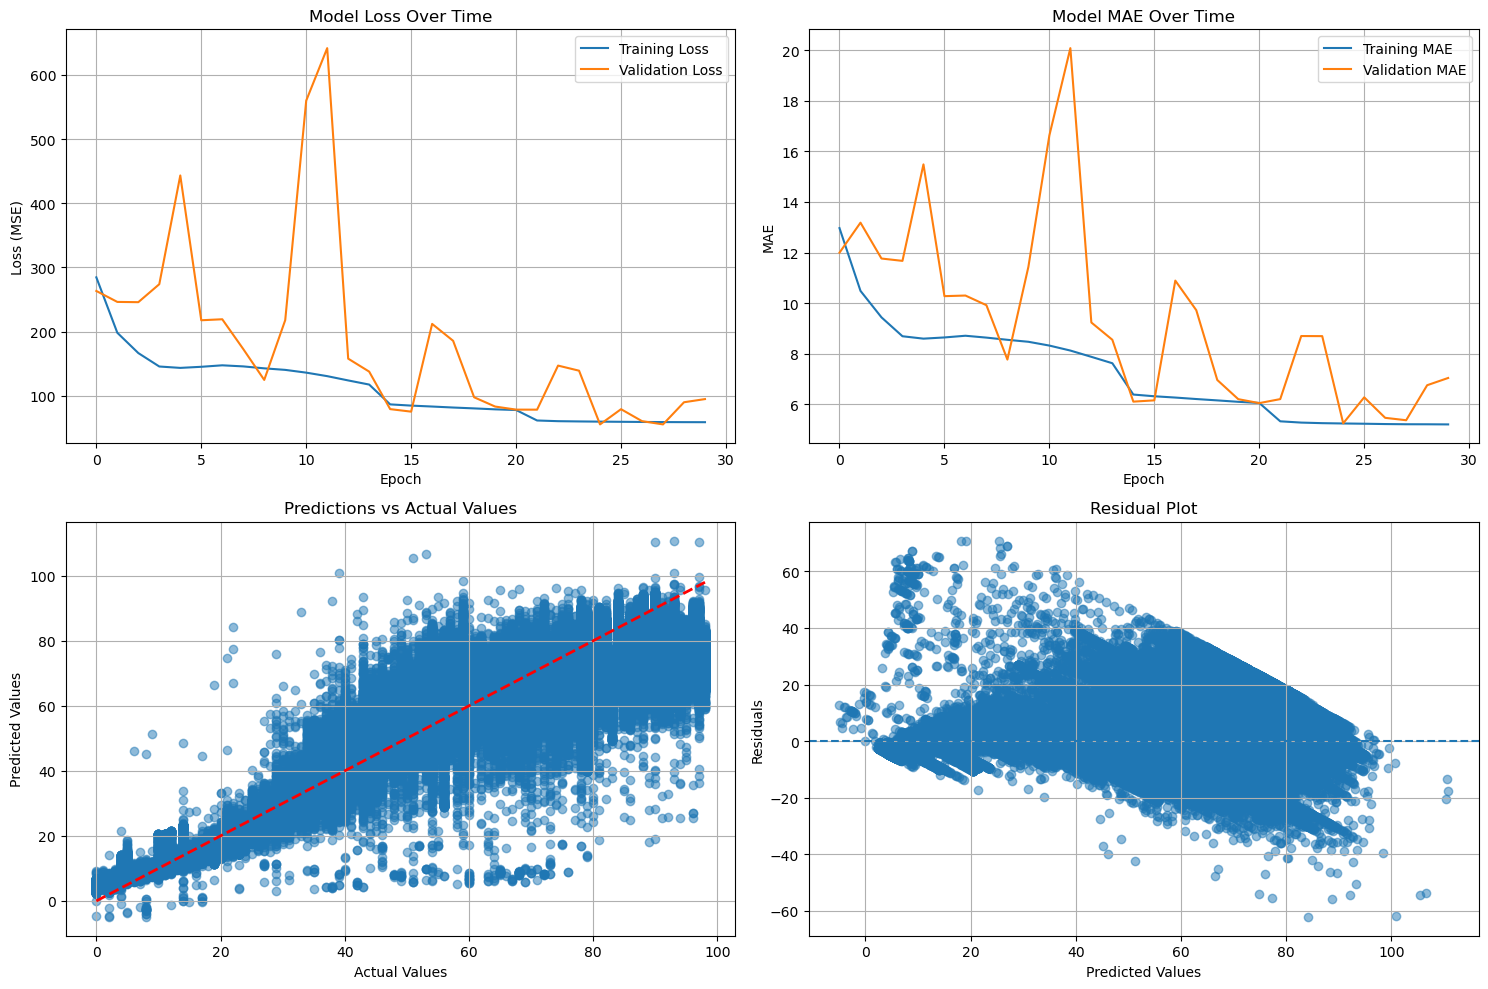

In [24]:
# Plot comprehensive training history and results (uses persistent history if available)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_dir = "runs/parallel_cnn_lstm"
history_csv = os.path.join(run_dir, "history.csv")

# ---- Load history ----
history_dict = None

if os.path.exists(history_csv):
    df_hist = pd.read_csv(history_csv)

    # Build a dict similar to Keras history.history
    history_dict = {col: df_hist[col].tolist() for col in df_hist.columns if col != "epoch"}
    print(f"✅ Loaded persistent history: {history_csv} ({len(df_hist)} epochs)")
elif 'history' in locals() and hasattr(history, "history"):
    history_dict = history.history
    print("ℹ️ Using in-memory `history` (no history.csv found).")
else:
    print("Cannot plot - no training history found.")
    history_dict = None

if history_dict is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Training and Validation Loss
    if "loss" in history_dict:
        axes[0, 0].plot(history_dict["loss"], label="Training Loss")
    if "val_loss" in history_dict:
        axes[0, 0].plot(history_dict["val_loss"], label="Validation Loss")
    axes[0, 0].set_title("Model Loss Over Time")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss (MSE)")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot 2: Training and Validation MAE
    if "mean_absolute_error" in history_dict:
        axes[0, 1].plot(history_dict["mean_absolute_error"], label="Training MAE")
    if "val_mean_absolute_error" in history_dict:
        axes[0, 1].plot(history_dict["val_mean_absolute_error"], label="Validation MAE")
    axes[0, 1].set_title("Model MAE Over Time")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Plot 3: Predictions vs Actual
    try:
        y_pred = model.predict(X_test, verbose=0)
        axes[1, 0].scatter(Y_test, y_pred, alpha=0.5)
        axes[1, 0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--", lw=2)
        axes[1, 0].set_title("Predictions vs Actual Values")
        axes[1, 0].set_xlabel("Actual Values")
        axes[1, 0].set_ylabel("Predicted Values")
        axes[1, 0].grid(True)
    except Exception as e:
        axes[1, 0].text(0.5, 0.5, f"Prediction plot failed:\n{e}", ha="center", va="center")
        axes[1, 0].set_axis_off()

    # Plot 4: Residuals
    try:
        residuals = Y_test.values.flatten() - y_pred.flatten()
        axes[1, 1].scatter(y_pred, residuals, alpha=0.5)
        axes[1, 1].axhline(y=0, linestyle="--")
        axes[1, 1].set_title("Residual Plot")
        axes[1, 1].set_xlabel("Predicted Values")
        axes[1, 1].set_ylabel("Residuals")
        axes[1, 1].grid(True)
    except Exception as e:
        axes[1, 1].text(0.5, 0.5, f"Residual plot failed:\n{e}", ha="center", va="center")
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()


In [25]:
# Save the complete results and model artifacts
import os
from datetime import datetime

run_dir = "runs/parallel_cnn_lstm"
os.makedirs(run_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_model_keras = os.path.join(run_dir, f"final_parallel_cnn_lstm_model_{timestamp}.keras")
final_model_h5 = os.path.join(run_dir, f"final_parallel_cnn_lstm_model_{timestamp}.h5")

# Save the current `model` if available
if 'model' in globals() and model is not None:
    model.save(final_model_keras)
    try:
        model.save(final_model_h5)
    except Exception as e:
        print(f"⚠️ Could not save H5 copy: {e}")

    print(f"✅ Saved final model to:\n- {final_model_keras}\n- {final_model_h5}")

    # Save best hyperparameters if they exist in this session
    if 'best_hps' in globals():
        hp_path = os.path.join(run_dir, f"best_hyperparameters_{timestamp}.txt")
        with open(hp_path, "w", encoding="utf-8") as f:
            f.write("BEST HYPERPARAMETERS FOR PARALLEL CNN-LSTM MODEL\n")
            f.write("=" * 60 + "\n\n")
            f.write("ARCHITECTURE:\n")
            f.write(f"CNN Layers: {best_hps.get('num_cnn_layers')}\n")
            f.write(f"LSTM Layers: {best_hps.get('num_lstm_layers')}\n")
            f.write(f"Dense Layers: {best_hps.get('num_dense_layers')}\n")
            f.write(f"CNN Pooling: {best_hps.get('cnn_pooling')}\n\n")
            f.write("OPTIMIZER:\n")
            f.write(f"Type: {best_hps.get('optimizer')}\n")
            f.write(f"Learning Rate: {best_hps.get('learning_rate')}\n\n")
        print(f"✅ Saved best hyperparameters to: {hp_path}")
    else:
        print("ℹ️ best_hps not found in this session (hyperparameter summary not saved).")
else:
    print("Cannot save final model - `model` is not available. Run build/train first.")


✅ Saved final model to:
- runs/parallel_cnn_lstm\final_parallel_cnn_lstm_model_20251223_020023.keras
- runs/parallel_cnn_lstm\final_parallel_cnn_lstm_model_20251223_020023.h5
✅ Saved best hyperparameters to: runs/parallel_cnn_lstm\best_hyperparameters_20251223_020023.txt


In [ ]:
# ========== FINAL TEST SET EVALUATION ==========
# Evaluate the best model on the ISOLATED test set
# This is the only time we use the test set

print("\n" + "="*70)
print("FINAL TEST SET EVALUATION")
print("="*70)
print("Evaluating best model on completely isolated test set...\n")

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on test set
test_loss, test_mae = best_model.evaluate(X_test, Y_test, verbose=0)

print(f"\nTest Set Performance (Final Evaluation):")
print(f"  Test Loss (MSE): {test_loss:.4f}")
print(f"  Test MAE: {test_mae:.4f}")

# Also show validation set performance for comparison
val_loss, val_mae = best_model.evaluate(X_val, Y_val, verbose=0)
print(f"\nValidation Set Performance (for reference):")
print(f"  Validation Loss (MSE): {val_loss:.4f}")
print(f"  Validation MAE: {val_mae:.4f}")

print(f"\nNote: The test set was completely isolated during hyperparameter tuning.")
print(f"These test metrics represent TRUE generalization performance.")
print("="*70 + "\n")
